# 보팅 앙상블

단일 모델을 앙상블하여 더 나은 예측을 하는 앙상블 모델을 만들어 보도록 하자.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import set_config
set_config(display="text")

from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.tree import DecisionTreeClassifier  # 의사결정트리
from sklearn.svm import SVC  # support vector Classification
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# 손글씨 데이터 로드

In [40]:
mnist = datasets.load_digits()
features, lables = mnist.data, mnist.target

X_train, X_test, y_train, y_test = train_test_split(features, lables, test_size=0.2) # 8(학습 데이터) : 2(태스트 데이터)의 비율로 split 

# 단일 모델 정확도 측정

의사결정트리, knn, svm 모델의 정확도를 측정

In [41]:
# 의사결정트리

dtree = DecisionTreeClassifier(criterion='gini', max_depth=8, 
                       max_features=32, random_state=35).fit(X_train, y_train)  # fit()까지 학습 완료

dtree_predicted = dtree.predict(X_test)  # 예측 모델 생성

In [42]:
# Knn 알고리즘

knn = KNeighborsClassifier(n_neighbors=299).fit(X_train, y_train)
knn_predicted = knn.predict(X_test)

In [43]:
# Support Vector Classification

svm = SVC(C=0.1, gamma=0.003, probability=True, random_state=35).fit(X_train, y_train)
svm_predicted = svm.predict(X_test)
svm_predicted

c:\workspaces\machine & deepLearning\src\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


array([6, 0, 1, 0, 8, 6, 7, 9, 7, 6, 0, 4, 3, 0, 8, 1, 2, 1, 9, 6, 5, 8,
       3, 5, 9, 7, 2, 3, 5, 2, 9, 0, 5, 6, 4, 5, 2, 4, 3, 0, 6, 9, 4, 8,
       1, 3, 7, 3, 9, 5, 5, 5, 4, 4, 0, 0, 7, 5, 2, 7, 2, 7, 5, 5, 7, 0,
       1, 5, 6, 7, 2, 5, 0, 8, 2, 8, 5, 5, 9, 6, 8, 1, 6, 4, 5, 6, 4, 1,
       5, 5, 1, 0, 8, 2, 5, 4, 1, 8, 3, 8, 1, 5, 7, 5, 5, 8, 5, 6, 9, 6,
       5, 0, 6, 6, 4, 4, 0, 3, 2, 8, 7, 5, 0, 8, 6, 8, 0, 2, 8, 5, 7, 5,
       4, 0, 9, 0, 8, 7, 7, 8, 0, 2, 8, 6, 5, 8, 4, 8, 5, 6, 9, 0, 8, 8,
       3, 4, 3, 3, 3, 6, 3, 0, 8, 6, 8, 5, 1, 8, 2, 3, 5, 3, 0, 8, 3, 3,
       5, 9, 3, 2, 8, 2, 4, 8, 2, 0, 5, 8, 8, 8, 3, 4, 2, 9, 3, 6, 5, 9,
       1, 8, 0, 7, 6, 2, 6, 9, 3, 2, 0, 4, 8, 5, 1, 7, 5, 4, 7, 8, 0, 2,
       8, 9, 4, 1, 5, 4, 5, 8, 6, 6, 6, 1, 8, 3, 9, 4, 3, 6, 0, 5, 0, 4,
       7, 0, 0, 4, 2, 2, 6, 8, 2, 2, 7, 9, 3, 5, 1, 1, 0, 6, 8, 4, 5, 8,
       6, 9, 7, 1, 1, 5, 9, 5, 9, 7, 4, 4, 3, 0, 8, 4, 2, 0, 5, 9, 7, 3,
       3, 0, 6, 1, 0, 8, 5, 8, 2, 0, 2, 4, 5, 5, 8,

In [44]:
# 동일한 데이터, 서로 다른 모델
print("[accuarcy]")
print('d-tree:', accuracy_score(y_test, dtree_predicted))
print('knn:', accuracy_score(y_test, knn_predicted))
print('svm:', accuracy_score(y_test, svm_predicted))

[accuarcy]
d-tree: 0.7944444444444444
knn: 0.8666666666666667
svm: 0.8472222222222222


### 소프트 보팅 또는 하드 보팅은 sklearn의 voting classifier를 사용하여 쉽게 구현할 수 있다.
##### 각 분류값별 확률을 더해준 값을 점수로 사용해 최대 점수를 가진 분류값을 결론으로 도출

In [45]:
# Support Vector Classification 적용

svm_proba = svm.predict_proba(X_test)
print(svm_proba[0:3])  # 총 3개 결과 데이터

[[1.03326882e-04 9.79766393e-06 1.48580518e-05 1.46828751e-05
  1.04446733e-05 1.15107045e-05 9.99789977e-01 1.41013372e-05
  1.81009915e-05 1.31994148e-05]
 [9.98525912e-01 8.26602276e-05 1.39909514e-04 2.10087274e-04
  7.44183832e-05 9.12389092e-05 2.41053860e-04 1.27471381e-04
  1.46624067e-04 3.60624151e-04]
 [2.36060053e-03 9.16493586e-01 7.84971814e-03 6.03682245e-03
  9.75607901e-03 4.98902328e-03 2.65057065e-03 7.33236703e-03
  2.78247002e-02 1.47065331e-02]]


In [46]:
# DecisionTreeClassifier 모델의 확률 값

dtree_proba = dtree.predict_proba(X_test)
print(dtree_proba)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]]


# 하드 보팅  

하드 보팅은 일반적인 투표와 같이, 각각의 분류기의 예측값들을 모아, 가장 많은 득표를 받은 예측값으로 최종 결론을 내는 방식.

In [47]:
# hard voting 모델 생성 (3개 모델 앙상블)

voting_clf = VotingClassifier(estimators=[('knn', knn), ('svm', svm), ('decision_tree', dtree)], 
                 weights=[1, 1, 1], voting='hard').fit(X_train, y_train)  # weights 가중치,voting='hard' 

hard_voting_predicted = voting_clf.predict(X_test)

c:\workspaces\machine & deepLearning\src\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [48]:
accuracy_score(y_test, hard_voting_predicted)

# hard voting 모델 적용 시 정확도

0.8972222222222223

# 소프트 보팅

소프트 보팅은 각각의 분류 모델의 predict_proba()을 활용하여, 모든 분류값들의 확률들을 더해서, 가장 높은 점수를 획득한 분류값으로 최종 결론을 내는 방식.

In [49]:
voting_clf = VotingClassifier(estimators=[('knn', knn), ('svm', svm), ('decision_tree', dtree)], 
                 weights=[1, 1, 1], voting='soft').fit(X_train, y_train)  # weights 가중치,voting='hard' 

soft_voting_predicted = voting_clf.predict(X_test)

c:\workspaces\machine & deepLearning\src\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [50]:
accuracy_score(y_test, soft_voting_predicted)

0.9083333333333333

# 정확도 비교 시각화

([<matplotlib.axis.XTick at 0x1eedf5c4e00>,
 [Text(0, 0, 'd-tree'),
  Text(1, 0, 'knn'),
  Text(2, 0, 'svm'),
  Text(3, 0, 'hard voting'),
  Text(4, 0, 'soft voting')])

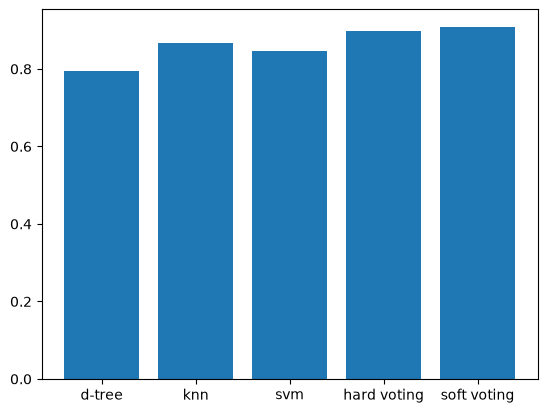

In [51]:
x = np.arange(5)
plt.bar(x, height=[accuracy_score(y_test, dtree_predicted),
                   accuracy_score(y_test, knn_predicted),
                   accuracy_score(y_test, svm_predicted),
                   accuracy_score(y_test, hard_voting_predicted),
                   accuracy_score(y_test, soft_voting_predicted)
                  ])
plt.xticks(x, ['d-tree', 'knn', 'svm', 'hard voting', 'soft voting'])